# Steel Industry Energy - hourly interval pipeline

Understanding LSTM behaviors using XAI (undergraduate research).

Data resampled to 1-hour intervals.

Run cells top to bottom in Google Colab. Models and XAI results save to Drive. If already saved, they load instead of retraining.


In [ ]:
FORCE_RETRAIN = False   # True = redo preprocess + retrain everything

window_sizes = [1, 4, 8, 12, 16, 24, 36, 48, 74, 168, 336, 672]
epochs = 50
batch_size = 32
test_ratio = 0.18

DRIVE_BASE = "/content/drive/MyDrive/Shared-Colab-Storage"
BASE_PATH = f"{DRIVE_BASE}/Final/hourly"


## Setup (Colab)


In [2]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn tensorflow shap

!git clone https://github.com/Dinith132/steel-industry-energy-consumption.git

from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## Imports


In [3]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from tensorflow.keras import backend as K
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.models import Sequential, load_model

def rmse(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_true - y_pred)))

os.makedirs(BASE_PATH, exist_ok=True)


## Load original dataset


In [4]:
DATA_PATH = "/content/steel-industry-energy-consumption/Steel_industry_data.csv"
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"], format='%d/%m/%Y %H:%M' )
df = df.sort_values("date").reset_index(drop=True)
print("Shape:", df.shape)
df.head()


Shape: (35040, 11)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,2018-01-01 00:00:00,3.42,3.46,0.0,0.0,70.30,100.0,0,Weekday,Monday,Light_Load
1,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
2,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
3,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
4,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load


## EDA (exploratory data analysis)


                      date     Usage_kWh  \
count                35040  35040.000000   
mean   2018-07-02 11:52:30     27.386892   
min    2018-01-01 00:00:00      0.000000   
25%    2018-04-02 05:56:15      3.200000   
50%    2018-07-02 11:52:30      4.570000   
75%    2018-10-01 17:48:45     51.237500   
max    2018-12-31 23:45:00    157.180000   
std                    NaN     33.444380   

       Lagging_Current_Reactive.Power_kVarh  \
count                          35040.000000   
mean                              13.035384   
min                                0.000000   
25%                                2.300000   
50%                                5.000000   
75%                               22.640000   
max                               96.910000   
std                               16.306000   

       Leading_Current_Reactive_Power_kVarh     CO2(tCO2)  \
count                          35040.000000  35040.000000   
mean                               3.870949      0.011524

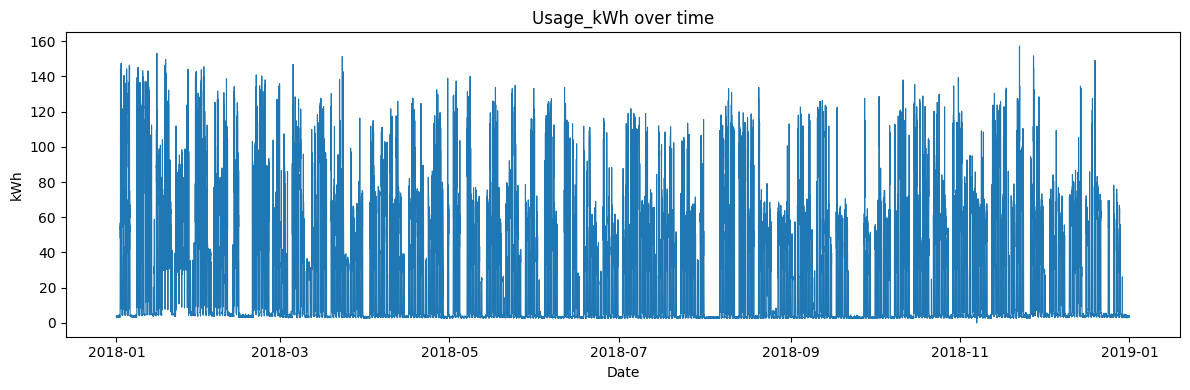

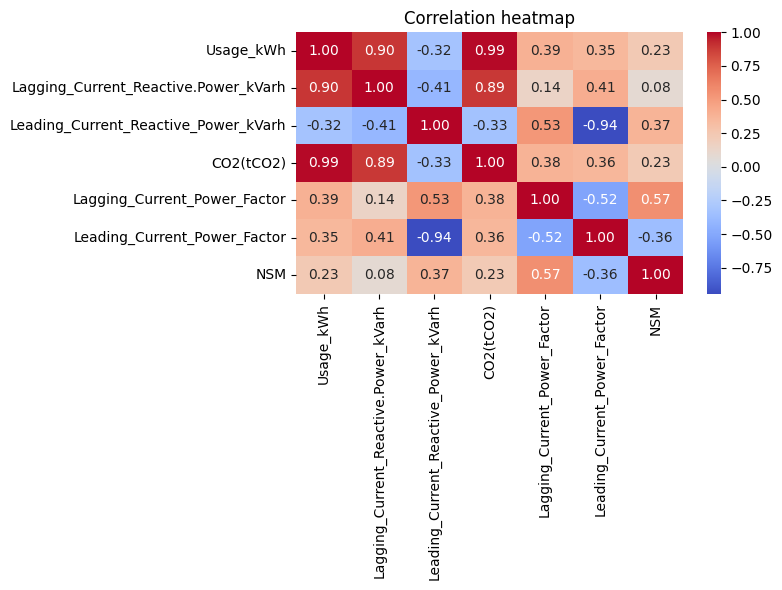

In [5]:
print(df.describe())

plot_dir = f"{BASE_PATH}/plots"
os.makedirs(plot_dir, exist_ok=True)

plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["Usage_kWh"], linewidth=0.8)
plt.title("Usage_kWh over time")
plt.xlabel("Date"); plt.ylabel("kWh")
plt.tight_layout()
plt.savefig(f"{plot_dir}/usage_timeseries.png", dpi=120)
plt.show()

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig(f"{plot_dir}/correlation.png", dpi=120)
plt.show()


## Preprocessing and feature engineering

Ordinal encoding, scaling, train/test split. Saves data.csv and scaler.pkl to Drive.


In [6]:
scaled_csv = f"{BASE_PATH}/data.csv"
scaler_pkl = f"{BASE_PATH}/scaler.pkl"

if os.path.exists(scaled_csv) and not FORCE_RETRAIN:
    print("Loading preprocessed data from Drive")
    scaled_df = pd.read_csv(scaled_csv)
    with open(scaler_pkl, "rb") as f:
        scaler = pickle.load(f)
    feature_cols = [c for c in scaled_df.columns]
else:
    for col in ["WeekStatus", "Load_Type", "Day_of_week"]:
        if col in df.columns and df[col].dtype == object:
            df[col] = OrdinalEncoder().fit_transform(df[[col]])
 
    df = df.set_index("date")
    agg = {c: "mean" for c in df.columns if c not in ["WeekStatus", "Load_Type", "Day_of_week"]}
    for c in ["WeekStatus", "Load_Type", "Day_of_week"]:
        if c in df.columns:
            agg[c] = "first"
    df = df.resample("h").agg(agg).reset_index()
    print("After hourly resample:", df.shape)

    target = "Usage_kWh"
    feature_cols = [target] + [c for c in df.columns if c not in ("date", target)]
    df = df[["date"] + feature_cols]

    split_idx = int(len(df) * (1 - test_ratio))
    train_df = df.iloc[:split_idx]
    test_df = df.iloc[split_idx:]

    scaler = MinMaxScaler()
    scaler.fit(train_df[feature_cols])
    train_s = train_df.copy()
    test_s = test_df.copy()
    train_s[feature_cols] = scaler.transform(train_df[feature_cols])
    test_s[feature_cols] = scaler.transform(test_df[feature_cols])
    scaled_df = pd.concat([train_s, test_s], ignore_index=True).drop(columns=["date"])

    scaled_df.to_csv(scaled_csv, index=False)
    pickle.dump(scaler, open(scaler_pkl, "wb"))
    print("Saved preprocessed data to Drive:", scaled_csv)

print(scaled_df.head())


Loading preprocessed data from Drive
   Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0   0.007306                              0.049021   
1   0.007638                              0.054599   
2   0.007840                              0.057752   
3   0.007288                              0.056123   
4   0.008484                              0.061112   

   Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
0                                   0.0        0.0   
1                                   0.0        0.0   
2                                   0.0        0.0   
3                                   0.0        0.0   
4                                   0.0        0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor       NSM  \
0                      0.497919                           1.0  0.000000   
1                      0.437513                           1.0  0.043478   
2                      0.407121                           1.0  0.086957   
3            

## Sliding windows


In [7]:
arr = scaled_df[feature_cols].to_numpy(dtype=np.float32)
target_idx = 0

data = {}
for window in window_sizes:
    X, y = [], []
    for i in range(len(arr) - window):
        X.append(arr[i:i+window])
        y.append(arr[i+window, target_idx])
    X, y = np.array(X), np.array(y)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_ratio, shuffle=False)
    data[f"win{window}"] = dict(X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)
    print(f"win{window}: train {X_train.shape}, test {X_test.shape}")


win1: train (7182, 1, 10), test (1577, 1, 10)
win4: train (7179, 4, 10), test (1577, 4, 10)
win8: train (7176, 8, 10), test (1576, 8, 10)
win12: train (7173, 12, 10), test (1575, 12, 10)
win16: train (7170, 16, 10), test (1574, 16, 10)
win24: train (7163, 24, 10), test (1573, 24, 10)
win36: train (7153, 36, 10), test (1571, 36, 10)
win48: train (7143, 48, 10), test (1569, 48, 10)
win74: train (7122, 74, 10), test (1564, 74, 10)
win168: train (7045, 168, 10), test (1547, 168, 10)
win336: train (6907, 336, 10), test (1517, 336, 10)
win672: train (6632, 672, 10), test (1456, 672, 10)


## Model training (Single / Double / BiLSTM)

Checks Drive first - if winN.keras exists, loads it instead of training again.


In [8]:
stacks = {"single": "single", "double": "double", "bidir": "bidir"}
trained = {}

for stack, folder in stacks.items():
    print("\n==========", stack.upper(), "LSTM ==========")
    model_dir = f"{BASE_PATH}/{folder}/models"
    hist_dir = f"{BASE_PATH}/{folder}/history"
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(hist_dir, exist_ok=True)
    trained[stack] = {}

    for window in window_sizes:
        model_path = f"{model_dir}/win{window}.keras"
        hist_path = f"{hist_dir}/win{window}_history.pkl"

        X_train = data[f"win{window}"]["X_train"]
        X_test = data[f"win{window}"]["X_test"]
        y_train = data[f"win{window}"]["y_train"]
        y_test = data[f"win{window}"]["y_test"]

        if os.path.exists(model_path) and not FORCE_RETRAIN:
            model = load_model(model_path, custom_objects={"rmse": rmse})
            hist = pickle.load(open(hist_path, "rb")) if os.path.exists(hist_path) else {}
            print(f"  win{window}: loaded from Drive")
            trained[stack][window] = {"model": model, "history": hist}
            continue

        print(f"  win{window}: training...")
        model = Sequential()
        if stack == "single":
            model.add(LSTM(64, input_shape=(window, X_train.shape[2])))
        elif stack == "double":
            model.add(LSTM(64, return_sequences=True, input_shape=(window, X_train.shape[2])))
            model.add(LSTM(64))
        else:
            model.add(Bidirectional(LSTM(64), input_shape=(window, X_train.shape[2])))
        model.add(Dropout(0.1))
        model.add(Dense(1))
        model.compile(optimizer="adam", loss=rmse, metrics=["mae"])

        hist = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                         validation_data=(X_test, y_test), verbose=1)
        model.save(model_path)
        pickle.dump(hist.history, open(hist_path, "wb"))
        print(f"  win{window}: saved to {model_path}")
        trained[stack][window] = {"model": model, "history": hist.history}



========== SINGLE LSTM ==========
  win1: loaded from Drive
  win4: loaded from Drive
  win8: loaded from Drive
  win12: loaded from Drive
  win16: loaded from Drive
  win24: loaded from Drive
  win36: loaded from Drive
  win48: loaded from Drive
  win74: loaded from Drive
  win168: loaded from Drive
  win336: loaded from Drive
  win672: loaded from Drive

========== DOUBLE LSTM ==========
  win1: loaded from Drive
  win4: loaded from Drive
  win8: loaded from Drive
  win12: loaded from Drive
  win16: loaded from Drive
  win24: loaded from Drive
  win36: loaded from Drive
  win48: loaded from Drive
  win74: loaded from Drive
  win168: loaded from Drive
  win336: loaded from Drive
  win672: loaded from Drive

========== BIDIR LSTM ==========
  win1: loaded from Drive
  win4: loaded from Drive
  win8: loaded from Drive
  win12: loaded from Drive
  win16: loaded from Drive
  win24: loaded from Drive
  win36: loaded from Drive
  win48: loaded from Drive
  win74: loaded from Drive
  win168

## Evaluation (RMSE, MAE, R2, WIA in kWh)


In [9]:
rows = []
for stack in trained:
    for window in window_sizes:
        if window not in trained[stack]:
            continue
        model = trained[stack][window]["model"]
        y_test = data[f"win{window}"]["y_test"]
        y_pred = model.predict(data[f"win{window}"]["X_test"], verbose=0).ravel()

        def to_kwh(v):
            d = np.zeros((len(v), len(feature_cols)))
            d[:, target_idx] = v
            return scaler.inverse_transform(d)[:, target_idx]
        yt, yp = to_kwh(y_test), to_kwh(y_pred)

        rmse_k = float(np.sqrt(mean_squared_error(yt, yp)))
        mae_k = float(mean_absolute_error(yt, yp))
        r2_k = float(r2_score(yt, yp))
        mean_obs = np.mean(yt)
        wia_k = float(1 - np.sum((yp-yt)**2) / np.sum((np.abs(yp-mean_obs)+np.abs(yt-mean_obs))**2))

        rows.append({"model": stack, "window": window,
                     "rmse_kwh": rmse_k, "mae_kwh": mae_k, "r2": r2_k, "wia": wia_k})

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(f"{BASE_PATH}/results_metrics.csv", index=False)
best = metrics_df.loc[metrics_df["rmse_kwh"].idxmin()]
print("Best model:\n", best)
metrics_df.sort_values("rmse_kwh").head(10)


Best model:
 model         double
window            24
rmse_kwh    8.899685
mae_kwh     4.832371
r2          0.910134
wia         0.976653
Name: 17, dtype: object


,model,window,rmse_kwh,mae_kwh,r2,wia
17,double,24,8.899685,4.832371,0.910134,0.976653
8,single,74,9.048688,4.929662,0.907411,0.975801
9,single,168,9.051276,5.285299,0.907813,0.975816
6,single,36,9.191874,5.165773,0.904213,0.974788
4,single,16,9.242462,5.068828,0.903041,0.975335
18,double,36,9.313292,5.142105,0.901666,0.974348
21,double,168,9.466494,5.438529,0.899161,0.973135
7,single,48,9.511612,5.327387,0.897541,0.972476
20,double,74,9.527829,5.425459,0.897346,0.973130
29,bidir,24,9.542302,5.479072,0.896688,0.973727


## XAI - SHAP and Integrated Gradients (per model)

Saves to Drive. Skips if file already exists.


In [10]:
xai_base = f"{BASE_PATH}/xai"
os.makedirs(xai_base, exist_ok=True)

for stack in trained:
    for window in window_sizes:
        if window not in trained[stack]:
            continue

        out_dir = f"{xai_base}/{stack}"
        os.makedirs(out_dir, exist_ok=True)
        shap_csv = f"{out_dir}/win{window}_shap.csv"
        ig_png = f"{out_dir}/win{window}_horizon.png"

        if os.path.exists(shap_csv) and os.path.exists(ig_png) and not FORCE_RETRAIN:
            print(f"XAI exists: {stack} win{window}")
            continue

        model = trained[stack][window]["model"]
        X_train = data[f"win{window}"]["X_train"]
        X_test = data[f"win{window}"]["X_test"]
        w, nf = window, X_train.shape[2]

        print(f"SHAP {stack} win{window}...")
        bg = X_train[:50].reshape(50, w * nf)
        test_flat = X_test[:15].reshape(15, w * nf)
        explainer = shap.KernelExplainer(
            lambda x: model.predict(x.reshape(-1, w, nf), verbose=0).ravel(), bg)
        sv = explainer.shap_values(test_flat, nsamples=40)
        labels = [f"t-{w-1-t}_{feature_cols[f]}" for t in range(w) for f in range(nf)]
        shap_df = pd.DataFrame({"feature": labels, "val": np.abs(sv).mean(0)})
        shap_df["attr"] = shap_df["feature"].str.replace(r"^t-\d+_", "", regex=True)
        shap_rank = shap_df.groupby("attr")["val"].sum().sort_values(ascending=False)
        shap_rank.to_csv(shap_csv)

        print(f"IG {stack} win{window}...")
        x = X_test[0]
        baseline = X_train.mean(axis=0)
        x_t = tf.convert_to_tensor(x[np.newaxis, ...], dtype=tf.float32)
        b_t = tf.convert_to_tensor(baseline[np.newaxis, ...], dtype=tf.float32)
        grads = tf.zeros_like(x_t)
        for alpha in tf.linspace(0.0, 1.0, 51):
            with tf.GradientTape() as tape:
                interp = b_t + alpha * (x_t - b_t)
                tape.watch(interp)
                pred = model(interp, training=False)
            grads += tape.gradient(pred, interp)
        attr = ((x_t - b_t) * (grads / 51.0)).numpy()[0]
        horizon = np.abs(attr).mean(axis=1)

        plt.figure(figsize=(7, 3))
        plt.plot(range(w), horizon, "o-")
        plt.xlabel("Lag"); plt.ylabel("|attribution|")
        plt.title(f"{stack} win{window} memory horizon")
        plt.tight_layout()
        plt.savefig(ig_png, dpi=120)
        plt.close()
        print(f"  saved {shap_csv} and {ig_png}")


SHAP single win1...


  0%|          | 0/15 [00:00<?, ?it/s]

IG single win1...
  saved /content/drive/MyDrive/Shared-Colab-Storage/Final/hourly/xai/single/win1_shap.csv and /content/drive/MyDrive/Shared-Colab-Storage/Final/hourly/xai/single/win1_horizon.png
SHAP single win4...


  0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 2 iterations, i.e. alpha=6.996e-03, with an active set of 2 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 3 iterations, i.e. alpha=4.156e-03, with an active set of 3 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=2.758e-03, with an active set of 7 regressors, and the smallest cholesky pivot element being 4

...

/usr/local/lib/python3.12/dist-packages/shap/explainers/_kernel.py:765: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this situation and get a regular matrix do one of the following:
1) turn up the number of samples,
2) turn up the L1 regularization with num_features(N) where N is less than the number of samples,
3) group features together to reduce the number of inputs that need to be explained.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 9 iterations, i.e. alpha=9.661e-02, with an active set of 8 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 

IG bidir win336...
  saved /content/drive/MyDrive/Shared-Colab-Storage/Final/hourly/xai/bidir/win336_shap.csv and /content/drive/MyDrive/Shared-Colab-Storage/Final/hourly/xai/bidir/win336_horizon.png
SHAP bidir win672...


  0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 8 iterations, i.e. alpha=4.313e-01, with an active set of 7 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/shap/explainers/_kernel.py:765: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this situation and get a regular matrix do one of the following:
1) turn up the number of samples,
2) turn up the L1 regularization with num_features(N) where N is less than the number of samples,
3) group features together to reduce the number of inputs that need to be explained.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 

IG bidir win672...
  saved /content/drive/MyDrive/Shared-Colab-Storage/Final/hourly/xai/bidir/win672_shap.csv and /content/drive/MyDrive/Shared-Colab-Storage/Final/hourly/xai/bidir/win672_horizon.png


## Conclusion


In [11]:
print("Done - hourly track")
print("Best model:", best["model"], "window", int(best["window"]), "RMSE kWh", round(best["rmse_kwh"], 4))
print("Drive folder:", BASE_PATH)
print("Re-run loads from Drive. FORCE_RETRAIN=True to redo everything.")


Done - hourly track
Best model: double window 24 RMSE kWh 8.8997
Drive folder: /content/drive/MyDrive/Shared-Colab-Storage/Final/hourly
Re-run loads from Drive. FORCE_RETRAIN=True to redo everything.
